In [1]:
# Cell 1: Installation and Imports
# =============================================
# Installation and Setup
# =============================================

!pip install ultralytics

import argparse
from ultralytics import YOLO
import os
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
from ultralytics.utils.torch_utils import select_device
import torch
import numpy as np
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [2]:
# Cell 2: Configuration
# =============================================
# Configuration Section
# =============================================

# Dataset configuration
DATA_CONFIG = """
path: /kaggle/input/hackfest25/data
train: 
  - train/images
  - val/images
val: 
  - train/images
  - val/images
test: test/images
nc: 3
names: ['FireExtinguisher', 'ToolBox', 'OxygenTank']
"""

# Hyperparameters
HYPERPARAMS = {
    'epochs': 100,
    'batch': 16,
    'imgsz': 640,
    'patience': 20,
    'optimizer': 'SGD',
    'momentum': 0.937,
    'lr0': 0.0005,
    'weight_decay': 0.0001,
    'cos_lr': True,
    'augment': True,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'fliplr': 0.5,
    'flipud': 0.5,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.01,
    'mosaic': 0.2,
    'mixup': 0.2,
    'copy_paste': 0.1,
    'erasing': 0.3,
    'dropout': 0.4,
    'workers': 8,
    'cache': 'disk',
    'save_period': 25,
    'deterministic': True,
    'nbs': 64,
    'conf': 0.5,
    'iou': 0.5,
    'overlap_mask': False,
    'single_cls': False
}

In [3]:
# Cell 3: Training Function
# =============================================
# Training Function
# =============================================

def train_model():
    """Train YOLOv8 model with specified hyperparameters"""
    print("Initializing training...")
    
    device = select_device('cuda' if torch.cuda.is_available() else 'cpu')
    
    with open('/kaggle/working/data.yaml', 'w') as f:
        f.write(DATA_CONFIG)
    
    model = YOLO("yolov8x.pt").to(device)
    
    results = model.train(
        data="/kaggle/working/data.yaml",
        device=device,
        **HYPERPARAMS
    )
    
    print("Training completed successfully!")
    return model

In [4]:
# Cell 4: Evaluation Function
# =============================================
# Test Set Evaluation Function
# =============================================

def evaluate_test_set(model):
    """Evaluate model on test set"""
    print("\nEvaluating model on test set...")
    
    device = select_device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Run validation
    results = model.val(data="/kaggle/working/data.yaml", split="test", conf=0.5, iou=0.5, device=device)
    
    # Debug: Print available keys in results.results_dict
    print("\nAvailable keys in results.results_dict:")
    print(list(results.results_dict.keys()))
    
    # Extract overall metrics
    metrics = results.results_dict
    overall_metrics = {
        'precision': metrics.get('metrics/precision(B)', 0.0),
        'recall': metrics.get('metrics/recall(B)', 0.0),
        'mAP50': metrics.get('metrics/mAP50(B)', 0.0),
        'mAP50-95': metrics.get('metrics/mAP50-95(B)', 0.0)
    }
    
    # Extract per-class metrics using results.box.ap (or class_result if available)
    class_metrics = []
    for cls_idx, cls_name in enumerate(results.names.values()):
        ap50 = results.box.ap50[cls_idx] if hasattr(results.box, 'ap50') else 0.0
        ap50_95 = results.box.ap[cls_idx] if hasattr(results.box, 'ap') else 0.0
        precision = results.box.p[cls_idx] if hasattr(results.box, 'p') else 0.0
        recall = results.box.r[cls_idx] if hasattr(results.box, 'r') else 0.0
        
        class_metrics.append({
            'name': cls_name,
            'precision': precision,
            'recall': recall,
            'mAP50': ap50,
            'mAP50-95': ap50_95
        })
    
    # Print metrics
    print(f"\nTest Set Evaluation Results:")
    print(f"{'Class':<20} {'P':<8} {'R':<8} {'mAP50':<8} {'mAP50-95':<8}")
    print("-" * 50)
    
    print(f"{'all':<20} "
          f"{overall_metrics['precision']:<8.3f} "
          f"{overall_metrics['recall']:<8.3f} "
          f"{overall_metrics['mAP50']:<8.3f} "
          f"{overall_metrics['mAP50-95']:<8.3f}")
    
    for cm in class_metrics:
        print(f"{cm['name']:<20} "
              f"{cm['precision']:<8.3f} "
              f"{cm['recall']:<8.3f} "
              f"{cm['mAP50']:<8.3f} "
              f"{cm['mAP50-95']:<8.3f}")
    
    return results

In [5]:
# Cell 5: Prediction Function
# =============================================
# Prediction Function
# =============================================

def run_predictions(model):
    """Run predictions on test set and generate submission"""
    print("\nStarting predictions...")
    
    device = select_device('cuda' if torch.cuda.is_available() else 'cpu')
    
    test_images_path = Path("/kaggle/input/hackfest25/data/test/images")
    output_dir = Path("/kaggle/working/predictions")
    labels_dir = output_dir / "labels"
    labels_dir.mkdir(parents=True, exist_ok=True)
    
    for img_path in test_images_path.glob("*"):
        if img_path.suffix.lower() not in ['.png', '.jpg', '.jpeg']:
            continue
            
        results = model.predict(img_path, conf=0.05, device=device)
        output_txt = labels_dir / f"{img_path.stem}.txt"
        
        with open(output_txt, "w") as f:
            for result in results:
                img_height, img_width = result.orig_shape
                for box in result.boxes.data:
                    x1, y1, x2, y2, conf, cls_id = box.tolist()
                    x_center = ((x1 + x2) / 2) / img_width
                    y_center = ((y1 + y2) / 2) / img_height
                    width = (x2 - x1) / img_width
                    height = (y2 - y1) / img_height
                    f.write(f"{int(cls_id)} {conf:.6f} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    print("Predictions generated successfully!")
    return labels_dir

In [6]:
# Cell 6: Submission Generation
# =============================================
# Submission Generation
# =============================================

def create_submission(labels_dir):
    """Create Kaggle submission file from predictions"""
    print("\nCreating submission file...")
    
    test_images_path = Path("/kaggle/input/hackfest25/data/test/images")
    output_csv = Path("/kaggle/working/submission.csv")
    
    test_images = {p.stem for p in test_images_path.glob("*") if p.suffix.lower() in ['.png', '.jpg', '.jpeg']}
    predictions = []
    
    for txt_file in labels_dir.glob("*.txt"):
        image_id = txt_file.stem
        with open(txt_file) as f:
            lines = [line.strip() for line in f if len(line.strip().split()) == 6]
        pred_str = " ".join(lines) if lines else "no boxes"
        predictions.append({"image_id": image_id, "prediction_string": pred_str})
    
    predicted_ids = {p["image_id"] for p in predictions}
    for missing_id in test_images - predicted_ids:
        predictions.append({"image_id": missing_id, "prediction_string": "no boxes"})
    
    pd.DataFrame(predictions).to_csv(output_csv, index=False)
    print(f"Submission saved to {output_csv}")

In [7]:
# Cell 7: Visualization Function
# =============================================
# Visualization Function
# =============================================

def visualize_results(model, results=None):
    """Visualize training, evaluation results, and generate confusion matrix"""
    try:
        # === Plot Test Set Evaluation Metrics ===
        if results is not None:
            print("\nVisualizing Test Set Evaluation Metrics...")
            metrics = results.results_dict
            class_names = list(results.names.values())
            class_names.insert(0, 'all')
            
            precisions = [metrics.get('metrics/precision(B)', 0)]
            recalls = [metrics.get('metrics/recall(B)', 0)]
            map50s = [metrics.get('metrics/mAP50(B)', 0)]
            map50_95s = [metrics.get('metrics/mAP50-95(B)', 0)]
            
            # Extract per-class metrics
            for cls_idx, cls_name in enumerate(results.names.values()):
                ap50 = results.box.ap50[cls_idx] if hasattr(results.box, 'ap50') else 0.0
                ap50_95 = results.box.ap[cls_idx] if hasattr(results.box, 'ap') else 0.0
                precision = results.box.p[cls_idx] if hasattr(results.box, 'p') else 0.0
                recall = results.box.r[cls_idx] if hasattr(results.box, 'r') else 0.0
                precisions.append(precision)
                recalls.append(recall)
                map50s.append(ap50)
                map50_95s.append(ap50_95)
                print(f"{cls_name}: P={precision:.3f}, R={recall:.3f}, mAP50={ap50:.3f}, mAP50-95={ap50_95:.3f}")
            
            x = np.arange(len(class_names))
            width = 0.2
            
            plt.figure(figsize=(12, 6))
            plt.bar(x - width*1.5, precisions, width, label='Precision')
            plt.bar(x - width*0.5, recalls, width, label='Recall')
            plt.bar(x + width*0.5, map50s, width, label='mAP50')
            plt.bar(x + width*1.5, map50_95s, width, label='mAP50-95')
            
            plt.xlabel('Classes')
            plt.ylabel('Metrics')
            plt.title('Test Set Evaluation Metrics')
            plt.xticks(x, class_names, rotation=45)
            plt.legend()
            plt.grid(True, axis='y')
            plt.tight_layout()
            plt.savefig('/kaggle/working/test_metrics.png')
            plt.show()
        
        # === Plot Training and Validation Metrics ===
        print("\nVisualizing Training and Validation Metrics...")
        try:
            metrics_df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")
            metrics_df.columns = metrics_df.columns.str.strip()
            
            plt.figure(figsize=(12, 6))
            plt.plot(metrics_df['metrics/mAP50(B)'], label='mAP50')
            plt.plot(metrics_df['metrics/mAP50-95(B)'], label='mAP50-95')
            plt.title('mAP Evolution')
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.legend()
            plt.grid()
            plt.savefig('/kaggle/working/map_evolution.png')
            plt.show()
            
            plt.figure(figsize=(12, 6))
            plt.plot(metrics_df['train/box_loss'], label='Train Box Loss')
            plt.plot(metrics_df['train/cls_loss'], label='Train Class Loss')
            plt.plot(metrics_df['val/box_loss'], label='Val Box Loss')
            plt.plot(metrics_df['val/cls_loss'], label='Val Class Loss')
            plt.title('Training and Validation Losses')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid()
            plt.savefig('/kaggle/working/losses.png')
            plt.show()
            
        except FileNotFoundError:
            print("Warning: results.csv not found. Skipping training metrics plots.")
        
        # === Display Evaluation Artifacts ===
        print("\nDisplaying Evaluation Artifacts...")
        try:
            confusion_matrix_path = '/kaggle/working/runs/detect/train/confusion_matrix.png'
            display(Image(filename=confusion_matrix_path))
            
            val_pred_path = '/kaggle/working/runs/detect/train/val_batch0_pred.jpg'
            display(Image(filename=val_pred_path))
        except Exception as e:
            print(f"Could not display evaluation artifacts: {e}")
        
        # === Generate and Plot Confusion Matrix ===
        print("\nGenerating Confusion Matrix...")
        try:
            if results is not None and hasattr(results, 'confusion_matrix'):
                cm = results.confusion_matrix.matrix
                class_names = list(results.names.values())
                
                plt.figure(figsize=(10, 8))
                sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', 
                           xticklabels=class_names, yticklabels=class_names)
                plt.title('Confusion Matrix - Test Set')
                plt.xlabel('Predicted')
                plt.ylabel('True')
                plt.tight_layout()
                plt.savefig('/kaggle/working/confusion_matrix_custom.png')
                plt.show()
            else:
                print("Confusion matrix data not available.")
        except Exception as e:
            print(f"Could not generate confusion matrix: {e}")
            
    except Exception as e:
        print(f"Error visualizing results: {e}")

Initializing training...
Ultralytics 8.3.111 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


100%|██████████| 131M/131M [00:00<00:00, 272MB/s] 


engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/kaggle/working/data.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=25, cache=disk, device=cuda:0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=False, mask_ratio=4, dropout=0.4, val=True, split=val, save_json=False, conf=0.5, iou=0.5, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, simp

100%|██████████| 755k/755k [00:00<00:00, 17.6MB/s]
E0000 00:00:1745127867.601540      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745127867.656659      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1   1844480  ultralytics.nn.modules.conv.Conv             [320, 640, 3, 2]              
  6                  -1  6  13117440  ultralytics.nn.modules.block.C2f             [640, 640, 6, True]           
  7                  -1  1   3687680  ultralytics

...

val: Skipping caching images to disk, directory not writeable ⚠️


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:28<00:00,  1.78s/it]


                   all        250        332      0.969      0.905      0.951      0.922
      FireExtinguisher        113        113      0.962      0.904       0.95      0.904
               ToolBox        120        120      0.967      0.875      0.928      0.913
            OxygenTank         99         99      0.979      0.935      0.977      0.949


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.8ms preprocess, 104.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/train2

Available keys in results.results_dict:
['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'fitness']

Test Set Evaluation Results:
Class                P        R        mAP50    mAP50-95
--------------------------------------------------
all                  0.969    0.905    0.951    0.922   
FireExtinguisher     0.962    0.904    0.950    0.904   
ToolBox              0.967    0.875    0.928    0.913   
OxygenTank           0.979    0.935    0.977    0.949   

Starting predictions...
Ultralytics 8.3.111 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)

image 1/1 /kaggle/input/hackfest25/data/test/images/1000000076.png: 384x640 1 FireExtinguisher, 146.8ms
Speed: 2.4ms preprocess, 146.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/hackfest25/data/test/images/000000115

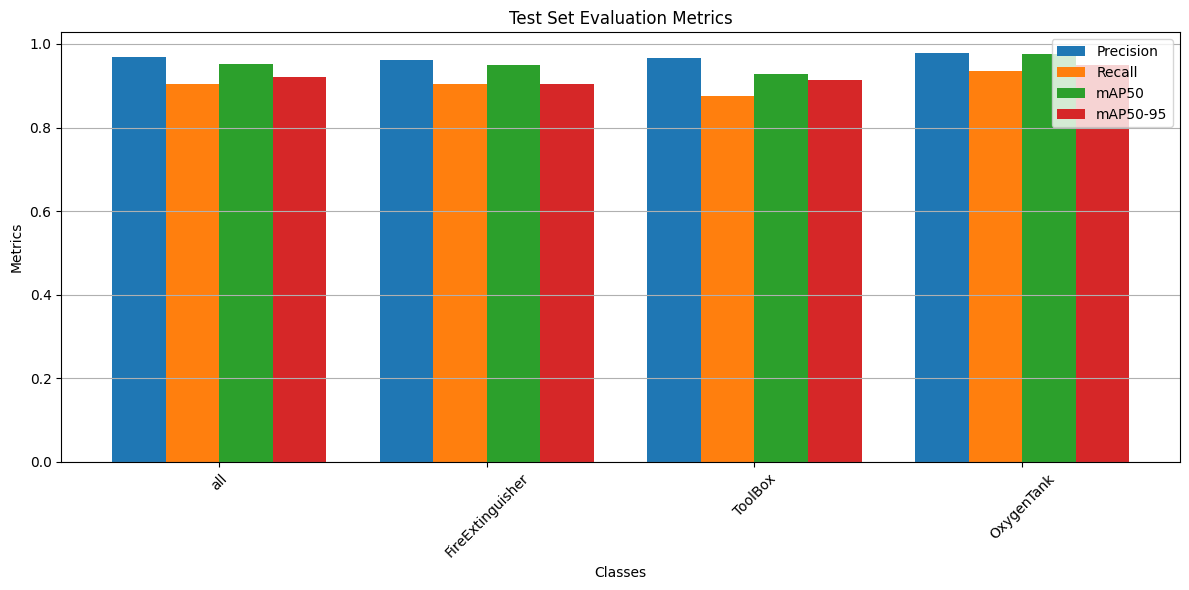


Visualizing Training and Validation Metrics...


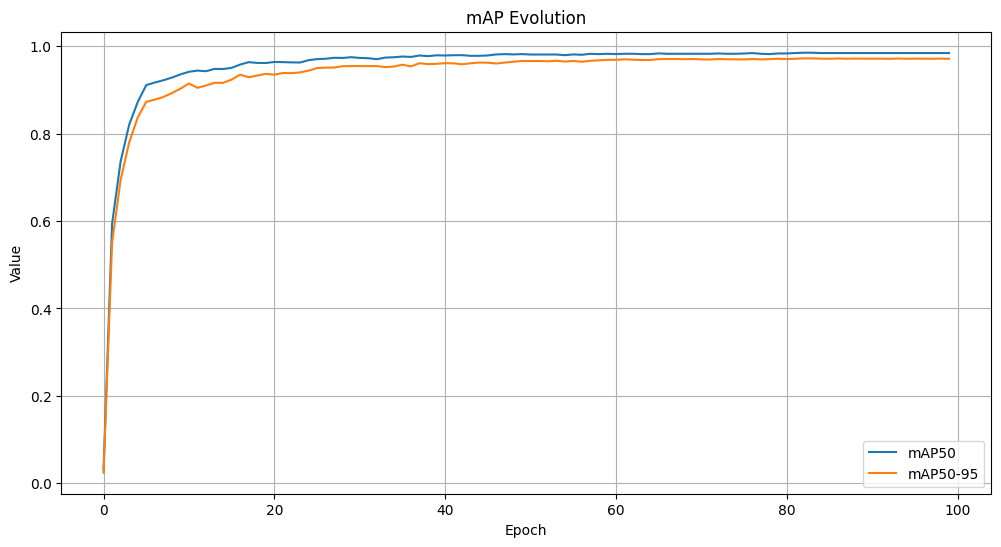

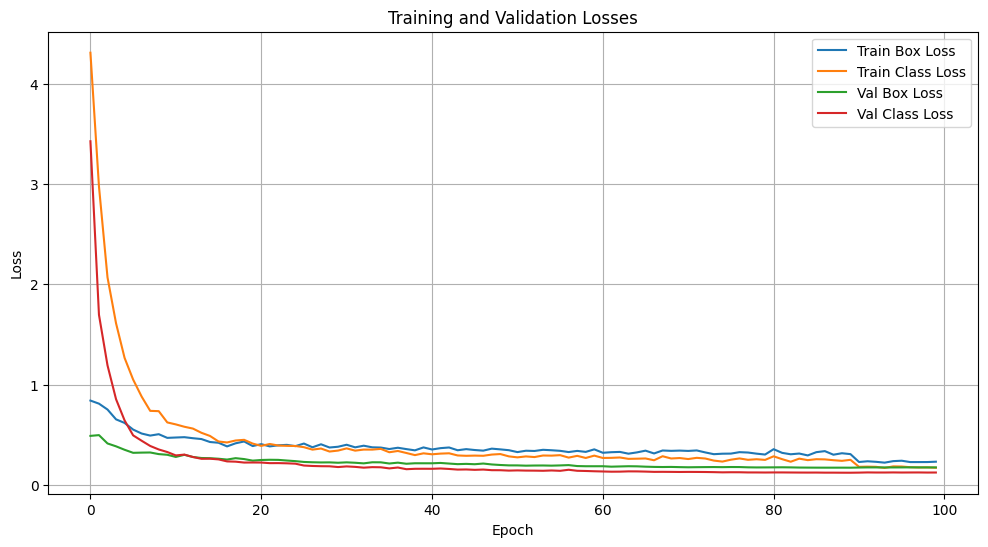


Displaying Evaluation Artifacts...


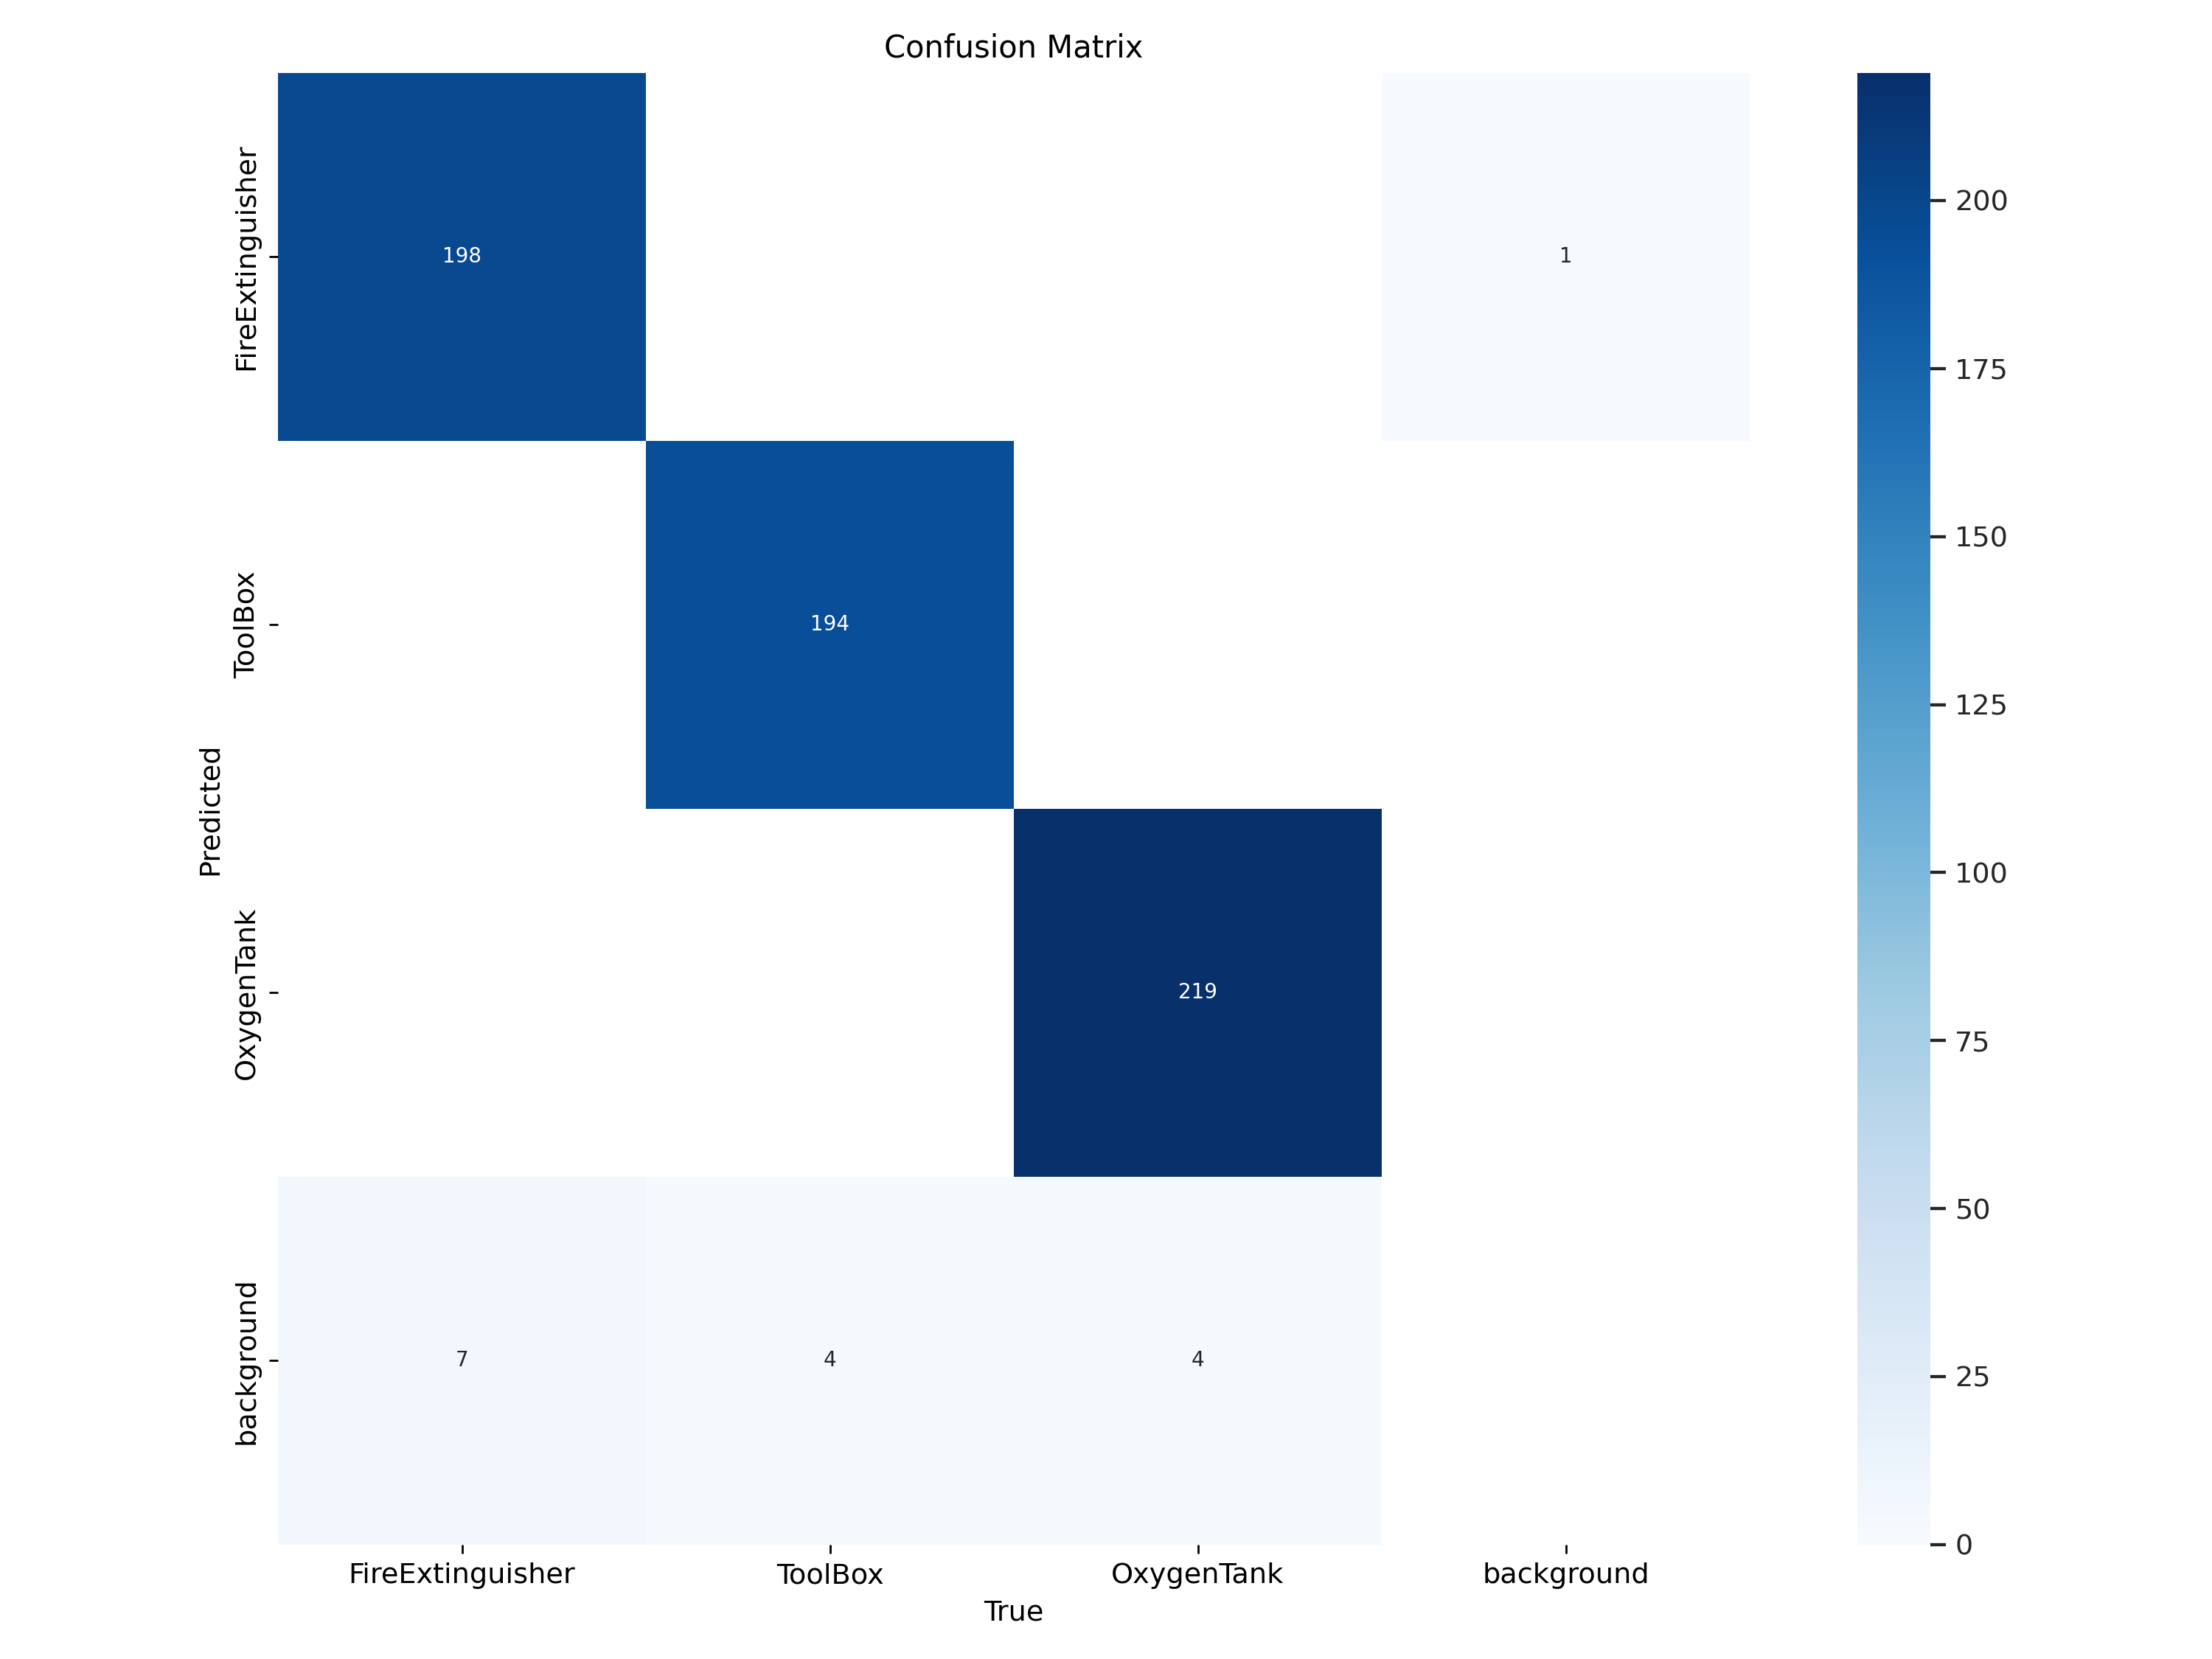

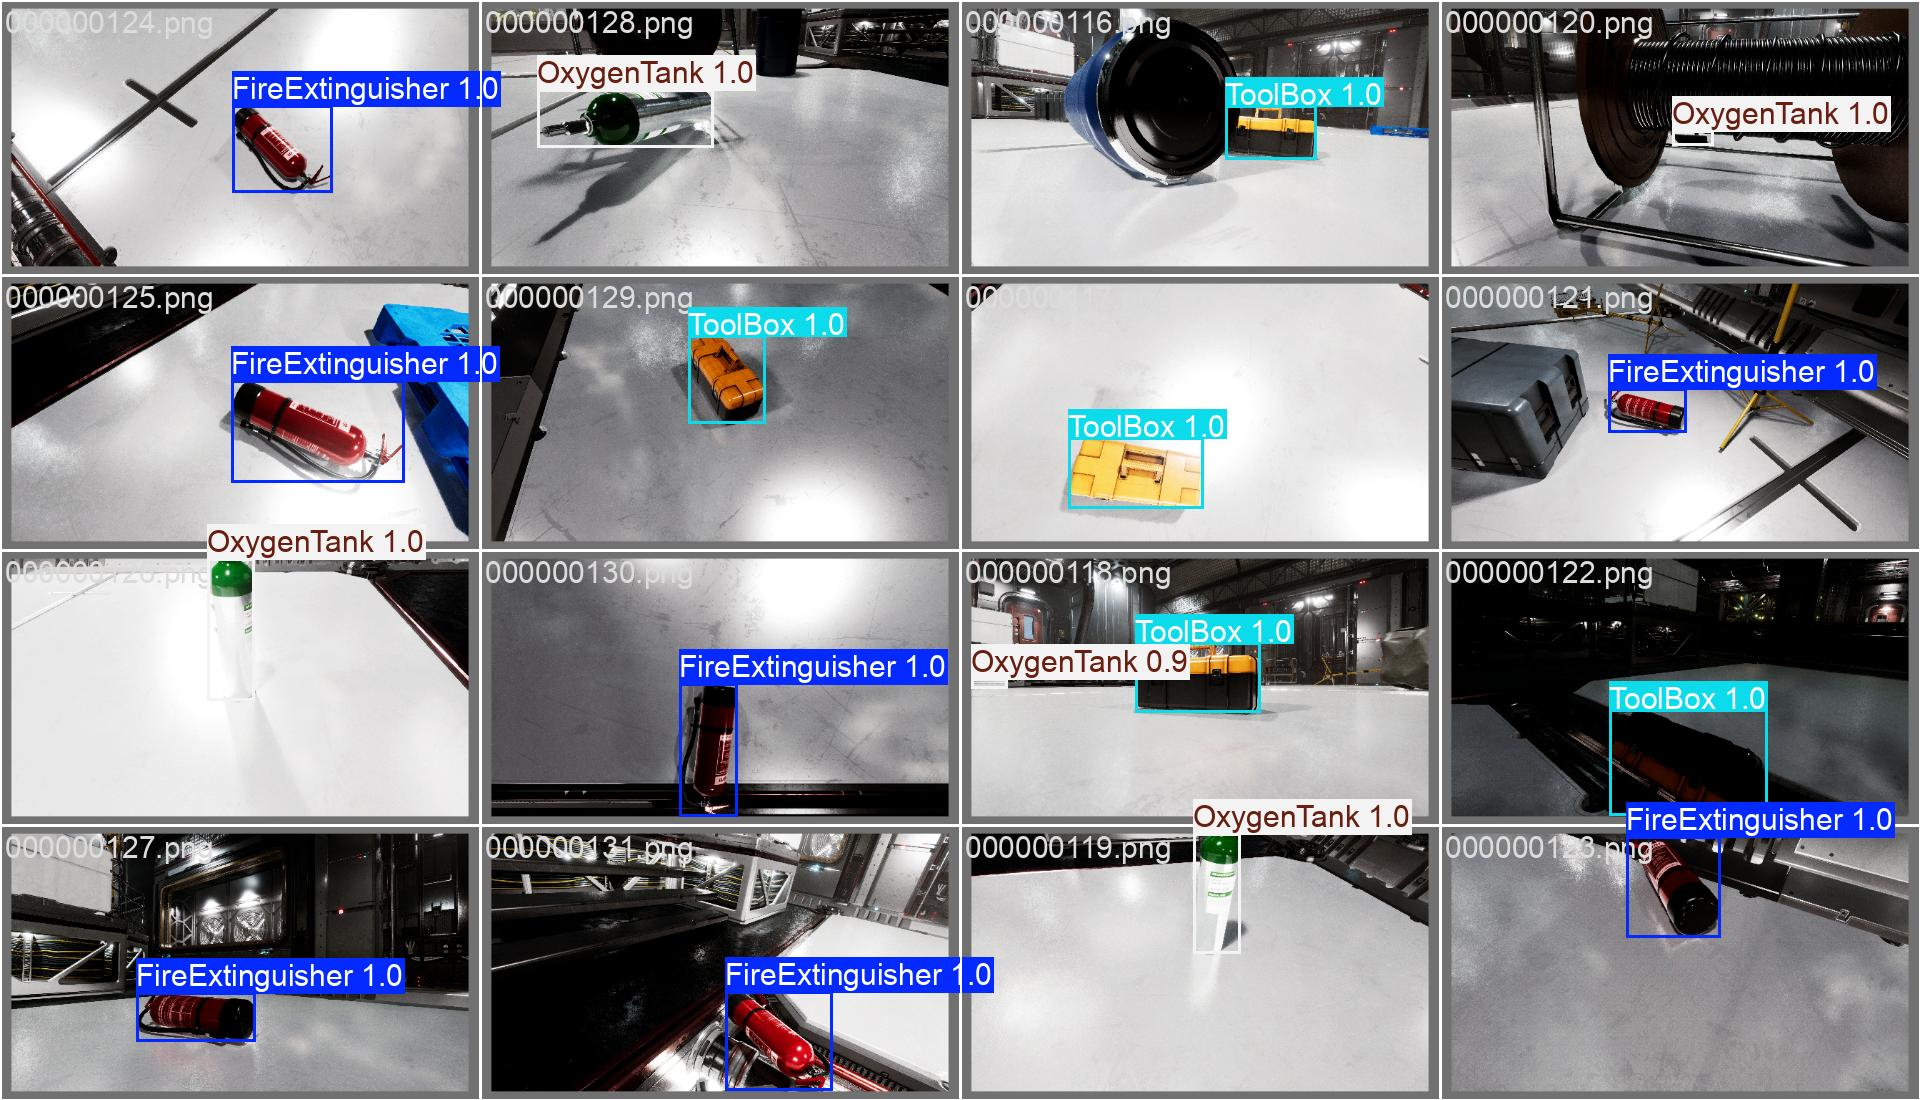


Generating Confusion Matrix...


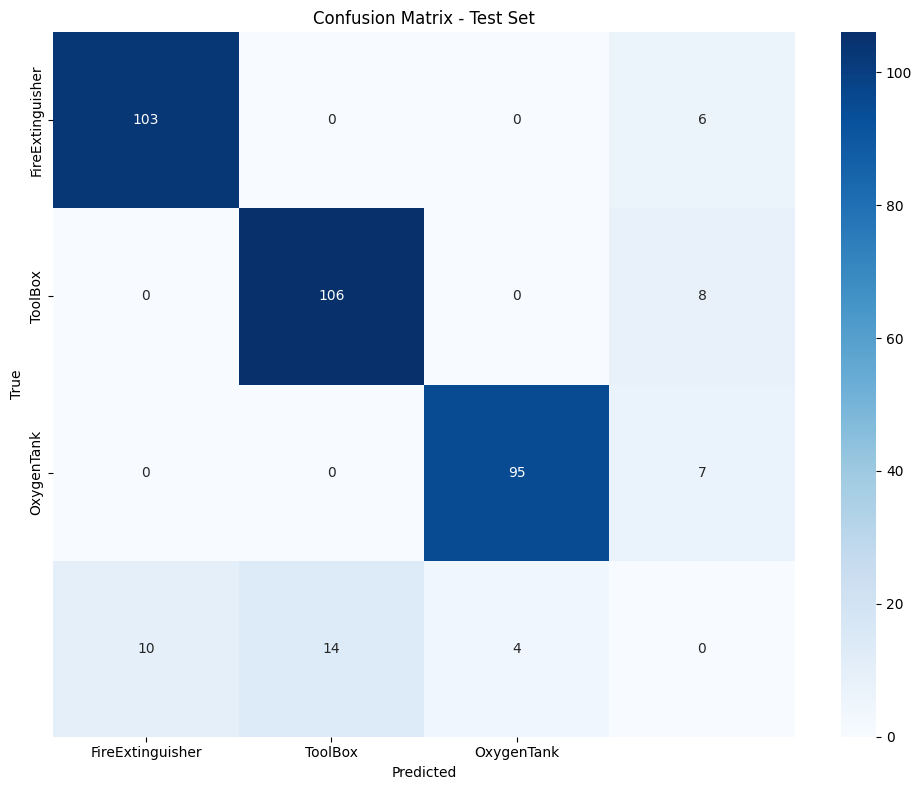


Pipeline execution completed successfully!


In [8]:
# Cell 8: Main Execution
# =============================================
# Main Execution
# =============================================

if __name__ == "__main__":
    # Step 1: Train the model
    trained_model = train_model()
    
    # Step 2: Evaluate on test set
    test_results = evaluate_test_set(trained_model)
    
    # Step 3: Run predictions
    predictions_dir = run_predictions(trained_model)
    
    # Step 4: Create submission
    create_submission(predictions_dir)
    
    # Step 5: Visualize results and generate confusion matrix
    visualize_results(trained_model, test_results)
    
    print("\nPipeline execution completed successfully!")